# Conformal Prediction for Directed Graph Link Prediction

This notebook presents a **directed link prediction** framework using **split conformal prediction** on the **Wikivitals** dataset. This produce prediction sets $C(x) \subseteq \{0, 1\}$ with guaranteed coverage at a chosen confidence level (e.g., 90%).

## Key Differences from Undirected Graphs

1. **Asymmetric adjacency matrix**: $A_{ij} \neq A_{ji}$ in general
2. **Directed embeddings**: Separate source and target embeddings
3. **In-degree and out-degree**: Two distinct degree metrics per node
4. **Directed features**: Asymmetric similarity and structural features

In [15]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sknetwork.embedding import SVD
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_fscore_support

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

## 1. Mathematical Foundations

### 1.1 Directed Graph Representation

A directed graph $G = (V, E)$ consists of:
- A set of vertices $V = \{v_1, v_2, \ldots, v_n\}$
- A set of directed edges $E \subseteq V \times V$, where $(u, v) \in E$ represents an edge from $u$ to $v$

The **adjacency matrix** $A \in \{0,1\}^{n \times n}$ is defined as:

$$
A_{ij} = \begin{cases}
1 & \text{if } (v_i \to v_j) \in E \\
0 & \text{otherwise}
\end{cases}
$$

Note: $A_{ij} = 1$ does NOT imply $A_{ji} = 1$ (asymmetry).

### 1.2 Node Degree Metrics

For a directed graph, each node $v_i$ has two degree measures:

**Out-degree** (number of outgoing edges):
$$
d^{\text{out}}_i = \sum_{j=1}^{n} A_{ij}
$$

**In-degree** (number of incoming edges):
$$
d^{\text{in}}_i = \sum_{j=1}^{n} A_{ji}
$$

### 1.3 Mondrian (Label-Conditional) Split Conformal Quantiles

For each class $y \in \{0, 1\}$, define the calibration index set and count:
$$\mathcal{I}_y = \{i \in \{1,\dots,n\} : y_i = y\}, \qquad n_y = |\mathcal{I}_y|$$

Compute the finite-sample rank:
$$k_y = \lceil (n_y + 1)(1 - \alpha) \rceil$$

The quantile $q_y$ is the $k_y$-th order statistic of the class-$y$ calibration scores:
$$q_y = s^{(y)}_{(k_y)} \quad \text{where} \quad s^{(y)}_{(1)} \le s^{(y)}_{(2)} \le \cdots \le s^{(y)}_{(n_y)}$$

**Non-conformity scores** (with $p_i = P(Y=1|x_i)$):
$$s(x, 1) = 1 - p(x), \qquad s(x, 0) = p(x)$$

**Class-conditional quantiles**:
$$q_1 = (1 - p_i)_{(k_1)}, \; i \in \mathcal{I}_1, \qquad q_0 = (p_i)_{(k_0)}, \; i \in \mathcal{I}_0$$

**Probability thresholds**:
$$t_{\text{upper}} = 1 - q_1, \qquad t_{\text{lower}} = q_0$$

If $k_y > n_y$, set $q_y = \infty$ to guarantee coverage.

This ensures marginal coverage: $\mathbb{P}(Y \in C(X)) \geq 1 - \alpha$.

In [16]:
def conformal_quantile(scores, alpha):
    """
    Mondrian (label-conditional) split conformal quantile.
    
    Returns the k-th order statistic where k = ceil((n+1)(1-alpha)).
    If k > n, returns infinity to guarantee coverage.
    
    Parameters:
    -----------
    scores : array-like
        Calibration non-conformity scores for a single class
    alpha : float
        Target error rate (e.g., 0.1 for 90% coverage)
    
    Returns:
    --------
    float : The conformal quantile threshold q_y
    """
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    
    # If k > n, return infinity to ensure coverage
    if k > n:
        return np.inf
    
    # Return the k-th order statistic (k-th smallest value)
    sorted_scores = np.sort(scores)
    return sorted_scores[k - 1]  # k-1 for 0-indexed array

print("Conformal quantile function ready.")

Conformal quantile function ready.


In [17]:
# =============================================================================
# A) Efficiency metrics for prediction sets
# =============================================================================
def set_metrics(y_true, sets):
    """
    Compute efficiency metrics for conformal prediction sets.
    
    Parameters:
    -----------
    y_true : array-like
        Ground truth labels
    sets : list of sets
        Prediction sets for each sample
    
    Returns:
    --------
    dict : Dictionary containing coverage, avg_set_size, abstention, retention, decided_acc
    """
    y_true = np.asarray(y_true)
    sizes = np.array([len(s) for s in sets])
    coverage = np.mean([y in s for y, s in zip(y_true, sets)])
    abstention = np.mean(sizes > 1)
    avg_set_size = np.mean(sizes)
    retention = 1 - abstention

    decided_idx = np.where(sizes == 1)[0]
    if len(decided_idx) > 0:
        y_dec = y_true[decided_idx]
        pred_dec = np.array([next(iter(sets[i])) for i in decided_idx])
        acc_dec = np.mean(pred_dec == y_dec)
    else:
        acc_dec = np.nan

    return {
        "coverage": coverage,
        "avg_set_size": avg_set_size,
        "abstention": abstention,
        "retention": retention,
        "decided_acc": acc_dec,
    }

# =============================================================================
# B) Non-conformal abstaining baseline matched to CP retention
# =============================================================================
def baseline_sets_from_margin(p, delta):
    """
    Generate prediction sets using margin-based abstention.
    
    Parameters:
    -----------
    p : array-like
        Predicted probabilities
    delta : float
        Margin threshold around 0.5
    
    Returns:
    --------
    list of sets : Prediction sets
    """
    sets = []
    for pi in p:
        if pi >= 0.5 + delta:
            sets.append({1})
        elif pi <= 0.5 - delta:
            sets.append({0})
        else:
            sets.append({0, 1})
    return sets

def choose_delta_to_match_retention(p_cal, target_retention):
    """
    Choose delta threshold to match a target retention rate.
    
    Parameters:
    -----------
    p_cal : array-like
        Calibration probabilities
    target_retention : float
        Target fraction of decided samples
    
    Returns:
    --------
    float : Delta threshold
    """
    conf = np.abs(p_cal - 0.5)
    # want fraction(conf >= delta) = target_retention => delta = quantile(conf, 1-target_retention)
    q = np.quantile(conf, 1 - target_retention)
    return float(q)

# =============================================================================
# C) Risk-coverage curve + AURC
# =============================================================================
def risk_coverage_curve(y_true, p):
    """
    Compute risk-coverage curve for selective prediction.
    
    Parameters:
    -----------
    y_true : array-like
        Ground truth labels
    p : array-like
        Predicted probabilities
    
    Returns:
    --------
    coverages : array
        Coverage values (fraction of samples included)
    risks : array
        Risk values (1 - accuracy) at each coverage level
    """
    y_true = np.asarray(y_true)
    conf = np.abs(p - 0.5)
    order = np.argsort(-conf)  # high confidence first

    risks = []
    coverages = []
    correct = ((p >= 0.5).astype(int) == y_true).astype(float)

    cum_correct = np.cumsum(correct[order])
    for k in range(1, len(y_true) + 1):
        cov = k / len(y_true)
        acc = cum_correct[k-1] / k
        risk = 1 - acc
        coverages.append(cov)
        risks.append(risk)

    return np.array(coverages), np.array(risks)

def aurc(coverages, risks):
    """
    Compute Area Under Risk-Coverage curve.
    
    Parameters:
    -----------
    coverages : array
        Coverage values
    risks : array
        Risk values
    
    Returns:
    --------
    float : AURC value (lower is better)
    """
    # trapezoidal integration over coverage in [0,1]
    return float(np.trapz(risks, coverages))

print("Efficiency metrics, baseline abstention, and AURC functions ready.")

Efficiency metrics, baseline abstention, and AURC functions ready.


## 2. Directed Graph Data Loading

### 2.1 Directed Adjacency Matrix Construction

For a directed graph, we construct the adjacency matrix **without** symmetrization:

$$
A_{ij} = 1 \iff (i \to j) \in E
$$

Key constraints:
- No self-loops: $A_{ii} = 0$ for all $i$
- Asymmetric: $A_{ij}$ is independent of $A_{ji}$

The input file format is:
```
source_node    target_node    True
```

where each line represents a directed edge from `source_node` to `target_node`.

In [18]:
def load_directed_graph_sparse(path):
    """
    Load a directed graph from a TSV file.
    
    Parameters:
    -----------
    path : str
        Path to adjacency.tsv file with columns: source, target, True
    
    Returns:
    --------
    scipy.sparse.csr_matrix : Directed adjacency matrix A where A[i,j] = 1 means i -> j
    """
    df = pd.read_csv(path, sep='\t', header=None, usecols=[0,1], names=['source', 'target'])
    
    # For directed graphs, we do NOT add reverse edges
    rows = df['source'].values
    cols = df['target'].values
    data = np.ones(len(rows))
    
    n_nodes = max(rows.max(), cols.max()) + 1
    
    # Create directed adjacency matrix
    adj = sp.csr_matrix((data, (rows, cols)), shape=(n_nodes, n_nodes))
    
    # Remove duplicates and self-loops
    adj.data = np.ones_like(adj.data)
    adj.setdiag(0)
    adj.eliminate_zeros()
    
    return adj

print("Directed graph loader ready.")

Directed graph loader ready.


## 3. Directed Graph Embeddings

### 3.1 Spectral Embeddings via SVD

For a directed adjacency matrix $A \in \mathbb{R}^{n \times n}$, we apply **Singular Value Decomposition**:

$$
A \approx U \Sigma V^T
$$

where:
- $U \in \mathbb{R}^{n \times k}$: **Source node embeddings** (captures outgoing edge patterns)
- $V \in \mathbb{R}^{n \times k}$: **Target node embeddings** (captures incoming edge patterns)
- $\Sigma \in \mathbb{R}^{k \times k}$: Singular values (diagonal)
- $k$: Embedding dimension (e.g., 32)

This gives us:
- **Source embedding** for node $i$: $u_i \in \mathbb{R}^k$ (row $i$ of $U$)
- **Target embedding** for node $j$: $v_j \in \mathbb{R}^k$ (row $j$ of $V$)

The reconstruction approximates: $A_{ij} \approx u_i^T \Sigma v_j$

### 3.2 Why Two Embeddings?

In directed graphs:
- A node's **role as a source** (outgoing edges) differs from its **role as a target** (incoming edges)
- Example: In a citation network, a paper cited by many (high in-degree) may cite few (low out-degree)
- Separate embeddings capture these asymmetric roles

In [19]:
def get_directed_node_features(adj, n_components=32):
    """
    Extract node features for directed graphs.
    
    Parameters:
    -----------
    adj : scipy.sparse matrix
        Directed adjacency matrix
    n_components : int
        Embedding dimension
    
    Returns:
    --------
    out_degrees : array, shape (n_nodes,)
        Out-degree of each node
    in_degrees : array, shape (n_nodes,)
        In-degree of each node
    source_embedding : array, shape (n_nodes, n_components)
        Source (row) embeddings from SVD
    target_embedding : array, shape (n_nodes, n_components)
        Target (column) embeddings from SVD
    """
    # Out-degrees: sum along columns (axis=1)
    out_degrees = np.array(adj.sum(axis=1)).flatten()
    
    # In-degrees: sum along rows (axis=0)
    in_degrees = np.array(adj.sum(axis=0)).flatten()
    
    # SVD Embeddings
    print(f"Computing SVD Embeddings (Rank {n_components}) for directed graph...")
    svd = SVD(n_components=n_components)
    
    # For directed graphs, sknetwork SVD returns row embeddings (U) and col embeddings (V)
    # fit_transform returns row embeddings (source embeddings)
    source_embedding = svd.fit_transform(adj)
    
    # Get column embeddings V (target embeddings) using correct sknetwork attribute
    target_embedding = svd.embedding_col_
    
    return out_degrees, in_degrees, source_embedding, target_embedding

print("Directed feature extractor ready.")

Directed feature extractor ready.


## 4. Feature Engineering for Directed Edge Prediction

### 4.1 Directed Edge Features

For a candidate directed edge $(u \to v)$, we construct feature vector $x_{u \to v}$:

$$
x_{u \to v} = \begin{bmatrix}
d^{\text{out}}_u \\
d^{\text{in}}_v \\
d^{\text{in}}_u \\
d^{\text{out}}_v \\
\text{sim}(u, v) \\
\text{sim}_{\text{reverse}}(v, u)
\end{bmatrix} \in \mathbb{R}^6
$$

where:

**Degree features** (capture node importance):
- $d^{\text{out}}_u$: Out-degree of source node (how many nodes $u$ points to)
- $d^{\text{in}}_v$: In-degree of target node (how many nodes point to $v$)
- $d^{\text{in}}_u$: In-degree of source node
- $d^{\text{out}}_v$: Out-degree of target node

**Directed similarity** (captures embedding compatibility):

$$
\text{sim}(u, v) = \frac{u_{\text{source}} \cdot v_{\text{target}}}{\|u_{\text{source}}\| \|v_{\text{target}}\|}
$$

This measures how well $u$'s outgoing pattern matches $v$'s incoming pattern.

**Reverse similarity** (captures potential reciprocity):

$$
\text{sim}_{\text{reverse}}(v, u) = \frac{v_{\text{source}} \cdot u_{\text{target}}}{\|v_{\text{source}}\| \|u_{\text{target}}\|}
$$

This measures the likelihood of the reverse edge $v \to u$.

### 4.2 Intuition

- If $u$ has high out-degree and $v$ has high in-degree, edge $u \to v$ is more likely (hub pattern)
- High $\text{sim}(u, v)$ means $u$'s outgoing neighbors are similar to $v$'s incoming neighbors
- High $\text{sim}_{\text{reverse}}(v, u)$ suggests potential reciprocal relationship

In [20]:
def compute_directed_pair_features(pairs, out_degrees, in_degrees, source_emb, target_emb):
    """
    Compute features for directed edge pairs (u -> v).
    
    Parameters:
    -----------
    pairs : array, shape (n_pairs, 2)
        Each row is [source, target] representing edge source -> target
    out_degrees : array
        Out-degree of each node
    in_degrees : array
        In-degree of each node
    source_emb : array, shape (n_nodes, k)
        Source embeddings (U from SVD)
    target_emb : array, shape (n_nodes, k)
        Target embeddings (V from SVD)
    
    Returns:
    --------
    features : array, shape (n_pairs, 6)
        Feature matrix with columns:
        [out_deg_u, in_deg_v, in_deg_u, out_deg_v, sim_forward, sim_reverse]
    """
    u = pairs[:, 0]  # Source nodes
    v = pairs[:, 1]  # Target nodes
    
    # Degree features
    out_deg_u = out_degrees[u]
    in_deg_v = in_degrees[v]
    in_deg_u = in_degrees[u]
    out_deg_v = out_degrees[v]
    
    # Forward similarity: u_source Â· v_target
    vec_u_source = source_emb[u]
    vec_v_target = target_emb[v]
    
    norm_u_source = np.linalg.norm(vec_u_source, axis=1)
    norm_v_target = np.linalg.norm(vec_v_target, axis=1)
    norm_u_source[norm_u_source == 0] = 1e-9
    norm_v_target[norm_v_target == 0] = 1e-9
    
    dot_forward = np.sum(vec_u_source * vec_v_target, axis=1)
    sim_forward = dot_forward / (norm_u_source * norm_v_target)
    
    # Reverse similarity: v_source Â· u_target (for reciprocity)
    vec_v_source = source_emb[v]
    vec_u_target = target_emb[u]
    
    norm_v_source = np.linalg.norm(vec_v_source, axis=1)
    norm_u_target = np.linalg.norm(vec_u_target, axis=1)
    norm_v_source[norm_v_source == 0] = 1e-9
    norm_u_target[norm_u_target == 0] = 1e-9
    
    dot_reverse = np.sum(vec_v_source * vec_u_target, axis=1)
    sim_reverse = dot_reverse / (norm_v_source * norm_u_target)
    
    return np.column_stack([out_deg_u, in_deg_v, in_deg_u, out_deg_v, sim_forward, sim_reverse])

print("Directed pair feature extractor ready.")

Directed pair feature extractor ready.


## 5. OGB Static Transductive Link Prediction


The idea is from the OGB transductive link prediction protocol, where the representation graph is constructed using training edges only, and validation/test edges are held out and used only for evaluation

Hu et al., Open Graph Benchmark: Datasets for Machine Learning on Graphs (NeurIPS 2020)
https://arxiv.org/abs/2005.00687

https://ogb.stanford.edu/docs/linkprop/
### 5.1 Edge Splitting (Exchangeability)

We randomly shuffle all directed edges $E$ and split them into disjoint sets:
$$
E = E_{\text{cal}} \cup E_{\text{test}} \cup E_{\text{train}}
$$
with $10\%$ for calibration, $10\%$ for testing, and $80\%$ for training.

### 5.2 Disjoint Message vs Supervision Edges (No Leakage)

Following the OGB protocol, we further split training edges:
$$
E_{\text{train}} = E_{\text{msg}} \cup E_{\text{sup}}, \quad E_{\text{msg}} \cap E_{\text{sup}} = \emptyset
$$

| Split | Purpose | Default |
|-------|---------|---------|
| $E_{\text{msg}}$ | Build representation graph $G_{\text{rep}}$ for SVD embeddings | 70% of $E_{\text{train}}$ |
| $E_{\text{sup}}$ | Classifier supervision (training labels) | 30% of $E_{\text{train}}$ |

This prevents the subtle leakage where the classifier learns to exploit edges already encoded in the SVD embeddings.

### 5.3 Representation Graph Construction

For directed graphs:
$$
G_{\text{rep}} = (V, E_{\text{msg}}) \quad \text{(asymmetric)}
$$
All node features (in/out-degrees, source/target SVD embeddings) are computed exclusively from $G_{\text{rep}}$.

### 5.4 Benchmark-Clean Negative Sampling

**Key principle**: Sampled negatives must be true non-edges. We exclude all observed edges in the dataset to ensure no false negatives contaminate the benchmark.

Define **all positive edges** (entire dataset):
$$
E_{\text{all}} = E_{\text{msg}} \cup E_{\text{sup}} \cup E_{\text{cal}} \cup E_{\text{test}}
$$

Negative sampling for all splits excludes $E_{\text{all}}$, guaranteeing that every sampled negative is a true non-edge.

| Split | Exclude Set | Rationale |
|-------|-------------|-----------|
| Train ($E_{\text{sup}}$) | $E_{\text{all}}$ | No false negatives |
| Calibration ($E_{\text{cal}}$) | $E_{\text{all}}$ | No false negatives |
| Test ($E_{\text{test}}$) | $E_{\text{all}}$ | No false negatives |

This ensures clean benchmark evaluation where label $y=0$ truly means "no edge exists."

### 5.5 Training & Conformal Calibration

1. Train classifier on $(E_{\text{sup}}^+, E_{\text{sup}}^-)$ using features from $G_{\text{rep}}$
2. Calibrate conformal thresholds on $(E_{\text{cal}}^+, E_{\text{cal}}^-)$
3. Evaluate on $(E_{\text{test}}^+, E_{\text{test}}^-)$

### 5.6 Non-conformity Scores

For each calibration sample $(x_i, y_i)$:
$$s_i(y) = \begin{cases}
1 - \hat{f}(x_i) & \text{if } y = 1 \\
\hat{f}(x_i) & \text{if } y = 0
\end{cases}$$

### 5.7 Prediction Sets

$$
C(x_{\text{test}}) = \{y \in \{0,1\} : s(x, y) \le q_y\}
$$

### 5.8 Coverage Guarantee

Under exchangeability: $\mathbb{P}(Y_{\text{test}} \in C(X_{\text{test}})) \geq 1 - \alpha$

In [21]:
FEATURE_NAMES_DIRECTED = ['out_deg_u', 'in_deg_v', 'in_deg_u', 'out_deg_v', 'sim_forward', 'sim_reverse']

def run_directed_pipeline(adj_path, name="dataset", alpha=0.10, n_runs=10, n_components=32, msg_ratio=0.7):
    """
    
    Parameters:
    -----------
    adj_path : str
        Path to directed adjacency.tsv file
    name : str
        Dataset name for display
    alpha : float
        Target error rate (1 - coverage)
    n_runs : int
        Number of random runs for averaging
    n_components : int
        SVD embedding dimension
    msg_ratio : float
        Fraction of training edges used for message passing / SVD (default 0.7)
        Remaining (1 - msg_ratio) used for classifier supervision
    
    Returns:
    --------
    results_df : DataFrame
        Results from all runs
    """
    print(f"\n{'='*50}")
    print(f"Running Directed Graph Pipeline: {name.upper()}")
    print(f"Averaging over {n_runs} runs")
    print(f"Message/Supervision split: {msg_ratio:.0%} / {1-msg_ratio:.0%}")
    print(f"{'='*50}")
    
    # Load directed graph
    adj = load_directed_graph_sparse(adj_path)
    n_nodes = adj.shape[0]
    print(f"Loaded directed graph: {n_nodes} nodes, {adj.nnz} edges")
    
    # Get all directed edges
    rows, cols = adj.nonzero()
    all_edges = np.column_stack([rows, cols])
    print(f"Total directed edges: {len(all_edges)}")
    
    # NEW: all observed positives in the dataset (built once outside the runs)
    all_pos_set = set(map(tuple, all_edges))
    
    run_results = []
    
    # Store last run data for visualization and error analysis
    last_run_data = {}
    
    for seed in range(n_runs):
        rng = np.random.default_rng(seed)
        
        # Shuffle edges for exchangeability
        edges = all_edges.copy()
        rng.shuffle(edges)
        
        # Split: 10% cal, 10% test, 80% train
        n = len(edges)
        n_cal = int(n * 0.1)
        n_test = int(n * 0.1)
        
        E_cal = edges[:n_cal]
        E_test = edges[n_cal:n_cal + n_test]
        E_train_all = edges[n_cal + n_test:]
        
        # OGB-style: Split training edges into message (for SVD) and supervision (for classifier)
        n_train = len(E_train_all)
        n_msg = int(n_train * msg_ratio)
        
        # Shuffle training edges before splitting
        train_idx = rng.permutation(n_train)
        E_msg = E_train_all[train_idx[:n_msg]]    # For building G_rep (SVD)
        E_sup = E_train_all[train_idx[n_msg:]]    # For classifier supervision
        
        # ============================================================
        # BENCHMARK-CLEAN NEGATIVE SAMPLING
        # ============================================================
        # known_edges_set: training edges used for exclude_set parameter
        # all_pos_set (built outside loop): excludes ALL observed edges to prevent false negatives
        known_edges_set = set(map(tuple, np.vstack([E_msg, E_sup])))
        
        # Build representation graph from MESSAGE edges only (not supervision edges)
        # For directed graphs, we do NOT add reverse edges
        msg_rows = E_msg[:, 0]
        msg_cols = E_msg[:, 1]
        msg_data = np.ones(len(msg_rows))
        adj_msg = sp.csr_matrix((msg_data, (msg_rows, msg_cols)), shape=(n_nodes, n_nodes))
        adj_msg.data = np.ones_like(adj_msg.data)
        adj_msg.setdiag(0)
        adj_msg.eliminate_zeros()
        
        # Compute features only from message graph
        out_deg, in_deg, src_emb, tgt_emb = get_directed_node_features(adj_msg, n_components)
        
        def make_dataset(pos_edges, exclude_set, all_pos_set):
            """
            Create balanced dataset with positive and negative edges.
            
            Parameters:
            -----------
            pos_edges : array
                Positive edge pairs for this split
            exclude_set : set
                Set of edges to exclude when sampling negatives.
                This should NOT include oracle knowledge of other splits' positives.
            all_pos_set : set
                All observed positive edges in the dataset (to avoid false negatives)
            """
            neg_edges = set()
            n_needed = len(pos_edges)
            
            # Sample non-edges, excluding only edges we legitimately know about
            while len(neg_edges) < n_needed:
                u, v = rng.integers(0, n_nodes, 2)
                if u == v:
                    continue
                if (u, v) in exclude_set:
                    continue
                if (u, v) in all_pos_set:          # NEW: forbid any observed edge
                    continue
                neg_edges.add((u, v))
            
            neg_edges = np.array(list(neg_edges))
            
            # Compute features
            X_pos = compute_directed_pair_features(pos_edges, out_deg, in_deg, src_emb, tgt_emb)
            X_neg = compute_directed_pair_features(neg_edges, out_deg, in_deg, src_emb, tgt_emb)
            
            X = np.vstack([X_pos, X_neg])
            y = np.hstack([np.ones(len(pos_edges)), np.zeros(len(neg_edges))])
            
            # Return pairs for error analysis
            all_pairs = np.vstack([pos_edges, neg_edges])
            
            return X, y, all_pairs, neg_edges
        
        # Train: exclude known training edges (E_msg + E_sup)
        X_train, y_train, _, train_neg = make_dataset(E_sup, exclude_set=known_edges_set, all_pos_set=all_pos_set)
        
        # Cal: exclude known edges + calibration positives (we know them when labeling cal)
        cal_exclude = known_edges_set | set(map(tuple, E_cal))
        X_cal, y_cal, _, cal_neg = make_dataset(E_cal, exclude_set=cal_exclude, all_pos_set=all_pos_set)
        
        # Test: exclude only known train edges (DO NOT exclude E_test positives - no oracle!)
        X_test, y_test, test_pairs, test_neg = make_dataset(E_test, exclude_set=known_edges_set, all_pos_set=all_pos_set)
        
        # Sanity check: ensure no negatives are observed edges (Fix #4a)
        overlap = sum((u, v) in all_pos_set for (u, v) in test_neg)
        assert overlap == 0, f"Negative sampling leaked {overlap} observed edges!"
        
        # Train classifier
        clf = GradientBoostingClassifier(random_state=seed, n_estimators=100)
        clf.fit(X_train, y_train)
        
        # Predict probabilities
        p_cal = clf.predict_proba(X_cal)[:, 1]
        p_test = clf.predict_proba(X_test)[:, 1]
        
        # Mondrian conformal quantiles
        scores_pos = 1 - p_cal[y_cal == 1]  # Score for y=1
        scores_neg = p_cal[y_cal == 0]      # Score for y=0
        
        q1 = conformal_quantile(scores_pos, alpha)
        q0 = conformal_quantile(scores_neg, alpha)
        
        # Thresholds
        t_lower = q0
        t_upper = 1 - q1
        
        # Generate prediction sets
        sets = []
        for p in p_test:
            s = set()
            if p <= t_lower:
                s.add(0)
            if p >= t_upper:
                s.add(1)
            if len(s) == 0:  # Abstain
                s = {0, 1}
            sets.append(s)
        
        # ============================================================
        # A) EFFICIENCY METRICS using set_metrics
        # ============================================================
        cp_metrics = set_metrics(y_test, sets)
        
        # Compute Coverage_pos and Coverage_neg
        y_test_arr = np.array(y_test)
        pos_mask = (y_test_arr == 1)
        neg_mask = (y_test_arr == 0)
        
        cov_pos = np.mean([y in s for y, s in zip(y_test_arr[pos_mask], np.array(sets, dtype=object)[pos_mask])]) if pos_mask.any() else np.nan
        cov_neg = np.mean([y in s for y, s in zip(y_test_arr[neg_mask], np.array(sets, dtype=object)[neg_mask])]) if neg_mask.any() else np.nan
        
        # F1 on decided samples
        decided_idx = [i for i, s in enumerate(sets) if len(s) == 1]
        if decided_idx:
            y_dec = y_test[decided_idx]
            p_dec = [list(sets[i])[0] for i in decided_idx]
            _, _, f1_dec, _ = precision_recall_fscore_support(y_dec, p_dec, average='binary', zero_division=0)
        else:
            f1_dec = 0.0
        
        # ============================================================
        # B) BASELINE COMPARISON: margin-based abstention matched to CP retention
        # ============================================================
        cp_retention = cp_metrics['retention']
        delta = choose_delta_to_match_retention(p_cal, cp_retention)
        baseline_sets = baseline_sets_from_margin(p_test, delta)
        baseline_metrics = set_metrics(y_test, baseline_sets)
        
        # ============================================================
        # C) RISK-COVERAGE CURVE + AURC
        # ============================================================
        rc_coverages, rc_risks = risk_coverage_curve(y_test, p_test)
        aurc_value = aurc(rc_coverages, rc_risks)
        
        # Baseline metrics
        auc = roc_auc_score(y_test, p_test)
        y_pred_std = (p_test >= 0.5).astype(int)
        _, _, base_f1, _ = precision_recall_fscore_support(y_test, y_pred_std, average='binary', zero_division=0)
        
        run_results.append({
            "AUC": auc,
            "AURC": aurc_value,
            "Base F1": base_f1,
            # CP metrics
            "CP Coverage": cp_metrics['coverage'],
            "CP Cov_pos": cov_pos,
            "CP Cov_neg": cov_neg,
            "CP Retention": cp_metrics['retention'],
            "CP Decided Acc": cp_metrics['decided_acc'],
            "CP Decided F1": f1_dec,
            "CP Avg Set Size": cp_metrics['avg_set_size'],
            # Baseline metrics (matched retention)
            "BL Coverage": baseline_metrics['coverage'],
            "BL Decided Acc": baseline_metrics['decided_acc'],
        })
        
        # Store last run data for visualization and error analysis
        last_run_data = {
            'clf': clf,
            'y_test': y_test,
            'p_test': p_test,
            'y_pred_std': y_pred_std,
            'X_test': X_test,
            'test_pairs': test_pairs,
            't_lower': t_lower,
            't_upper': t_upper,
            'sets': sets,
            'baseline_sets': baseline_sets,
            'auc': auc,
            'aurc': aurc_value,
            'rc_coverages': rc_coverages,
            'rc_risks': rc_risks,
            'delta': delta,
        }
        
        print(f"Run {seed+1}/{n_runs}: AUC={auc:.4f} | AURC={aurc_value:.4f} | "
              f"CP[Cov={cp_metrics['coverage']:.3f}, Ret={cp_retention:.3f}, Acc={cp_metrics['decided_acc']:.3f}] | "
              f"BL[Cov={baseline_metrics['coverage']:.3f}, Acc={baseline_metrics['decided_acc']:.3f}]")
    
    # Aggregate results
    df = pd.DataFrame(run_results)
    means = df.mean()
    stds = df.std()
    
    print(f"\n{'='*60}")
    print(f"FINAL RESULTS ({name.upper()})")
    print(f"{'='*60}")
    print(f"Splits: E_msg={n_msg}, E_sup={n_train-n_msg}, E_cal={n_cal}, E_test={n_test}")
    print(f"\n--- Classifier Performance ---")
    for col in ["AUC", "AURC", "Base F1"]:
        print(f"  {col:18s}: {means[col]:.4f} ± {stds[col]:.4f}")
    print(f"\n--- Conformal Prediction (α={alpha}) ---")
    for col in ["CP Coverage", "CP Cov_pos", "CP Cov_neg", "CP Retention", "CP Decided Acc", "CP Decided F1", "CP Avg Set Size"]:
        print(f"  {col:18s}: {means[col]:.4f} ± {stds[col]:.4f}")
    print(f"\n--- Baseline (margin δ matched to CP retention) ---")
    for col in ["BL Coverage", "BL Decided Acc"]:
        print(f"  {col:18s}: {means[col]:.4f} ± {stds[col]:.4f}")
    
    # ==========================================
    # FEATURE IMPORTANCE ANALYSIS (Last Run)
    # ==========================================
    print(f"\n{'='*50}")
    print(f"FEATURE IMPORTANCE (Last Run)")
    print(f"{'='*50}")
    
    clf = last_run_data['clf']
    feature_importance = clf.feature_importances_
    sorted_idx = np.argsort(feature_importance)[::-1]
    
    feat_names = FEATURE_NAMES_DIRECTED
    for i, idx in enumerate(sorted_idx):
        print(f"{i+1}. {feat_names[idx]}: {feature_importance[idx]:.4f}")
    
    # ==========================================
    # ERROR ANALYSIS (Last Run)
    # ==========================================
    print(f"\n{'='*50}")
    print(f"ERROR ANALYSIS (Last Run)")
    print(f"{'='*50}")
    
    y_test = last_run_data['y_test']
    p_test = last_run_data['p_test']
    y_pred_std = last_run_data['y_pred_std']
    X_test = last_run_data['X_test']
    test_pairs = last_run_data['test_pairs']
    
    # Identify false positives and false negatives
    fp_indices = np.where((y_test == 0) & (y_pred_std == 1))[0]
    fn_indices = np.where((y_test == 1) & (y_pred_std == 0))[0]
    
    # Sort by confidence (how wrong the model was)
    fp_sorted = fp_indices[np.argsort(p_test[fp_indices])[::-1]] if len(fp_indices) > 0 else []
    fn_sorted = fn_indices[np.argsort(p_test[fn_indices])] if len(fn_indices) > 0 else []
    
    print(f"\nTotal False Positives: {len(fp_indices)}")
    print(f"Total False Negatives: {len(fn_indices)}")
    
    print(f"\n--- Top 10 False Positives (predicted edge, actual non-edge) ---")
    print(f"{'Rank':<5} {'Pair (u->v)':<20} {'Prob':<8} {' | '.join([f'{f[:8]:<10}' for f in feat_names])}")
    print("-" * (35 + 11 * len(feat_names)))
    for rank, idx in enumerate(fp_sorted[:10], 1):
        pair = test_pairs[idx]
        prob = p_test[idx]
        feats = X_test[idx]
        feat_str = ' | '.join([f'{feats[i]:<10.2f}' for i in range(len(feat_names))])
        print(f"{rank:<5} ({pair[0]}->{pair[1]})".ljust(25) + f" {prob:<8.4f} {feat_str}")
    
    print(f"\n--- Top 10 False Negatives (predicted non-edge, actual edge) ---")
    print(f"{'Rank':<5} {'Pair (u->v)':<20} {'Prob':<8} {' | '.join([f'{f[:8]:<10}' for f in feat_names])}")
    print("-" * (35 + 11 * len(feat_names)))
    for rank, idx in enumerate(fn_sorted[:10], 1):
        pair = test_pairs[idx]
        prob = p_test[idx]
        feats = X_test[idx]
        feat_str = ' | '.join([f'{feats[i]:<10.2f}' for i in range(len(feat_names))])
        print(f"{rank:<5} ({pair[0]}->{pair[1]})".ljust(25) + f" {prob:<8.4f} {feat_str}")
    
    # ==========================================
    # VISUALIZATION (Last Run)
    # ==========================================
    t_lower = last_run_data['t_lower']
    t_upper = last_run_data['t_upper']
    sets = last_run_data['sets']
    auc = last_run_data['auc']
    rc_coverages = last_run_data['rc_coverages']
    rc_risks = last_run_data['rc_risks']
    
    plt.figure(figsize=(18, 10))
    
    # Plot 1: ROC curve
    plt.subplot(2, 4, 1)
    fpr, tpr, _ = roc_curve(y_test, p_test)
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}", color='blue', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {name.upper()}')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Plot 2: Risk-Coverage curve
    plt.subplot(2, 4, 2)
    plt.plot(rc_coverages, rc_risks, color='purple', linewidth=2, label=f'AURC={last_run_data["aurc"]:.4f}')
    plt.fill_between(rc_coverages, rc_risks, alpha=0.3, color='purple')
    plt.xlabel('Coverage')
    plt.ylabel('Risk (1 - Accuracy)')
    plt.title('Risk-Coverage Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Plot 3: Probability distributions
    plt.subplot(2, 4, 3)
    sns.histplot(p_test[y_test == 0], label='No Edge (y=0)', color='red', alpha=0.4, kde=True, bins=30)
    sns.histplot(p_test[y_test == 1], label='Edge (y=1)', color='blue', alpha=0.4, kde=True, bins=30)
    plt.axvline(t_lower, color='red', linestyle='--', linewidth=2, label=f't_lower={t_lower:.3f}')
    plt.axvline(t_upper, color='blue', linestyle='--', linewidth=2, label=f't_upper={t_upper:.3f}')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Count')
    plt.title('Conformal Thresholds')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Plot 4: Prediction set sizes
    plt.subplot(2, 4, 4)
    set_sizes = [len(s) for s in sets]
    unique, counts = np.unique(set_sizes, return_counts=True)
    plt.bar(unique, counts, color=['green', 'orange'], alpha=0.7)
    plt.xlabel('Prediction Set Size')
    plt.ylabel('Count')
    plt.title('Prediction Set Size Distribution')
    plt.xticks([1, 2], ['Decided', 'Abstain'])
    plt.grid(alpha=0.3, axis='y')
    
    # Plot 5: Feature Importance
    plt.subplot(2, 4, 5)
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(feat_names)))
    sorted_importance = [feature_importance[i] for i in sorted_idx]
    sorted_names = [feat_names[i] for i in sorted_idx]
    bars = plt.barh(range(len(sorted_names)), sorted_importance[::-1], color=colors)
    plt.yticks(range(len(sorted_names)), sorted_names[::-1])
    plt.xlabel("Importance")
    plt.title(f"Feature Importance: {name.upper()}")
    for i, (bar, val) in enumerate(zip(bars, sorted_importance[::-1])):
        plt.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
    plt.grid(alpha=0.3, axis='x')
    
    # Plot 6: Error Distribution
    plt.subplot(2, 4, 6)
    if len(fp_indices) > 0:
        plt.hist(p_test[fp_indices], bins=20, alpha=0.5, label=f'False Positives (n={len(fp_indices)})', color='orange')
    if len(fn_indices) > 0:
        plt.hist(p_test[fn_indices], bins=20, alpha=0.5, label=f'False Negatives (n={len(fn_indices)})', color='purple')
    plt.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title("Error Distribution")
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Plot 7: CP vs Baseline comparison
    plt.subplot(2, 4, 7)
    methods = ['Conformal', 'Baseline']
    coverages = [means['CP Coverage'], means['BL Coverage']]
    accs = [means['CP Decided Acc'], means['BL Decided Acc']]
    x = np.arange(len(methods))
    width = 0.35
    bars1 = plt.bar(x - width/2, coverages, width, label='Coverage', color='steelblue', alpha=0.8)
    bars2 = plt.bar(x + width/2, accs, width, label='Decided Acc', color='coral', alpha=0.8)
    plt.axhline(1-alpha, color='red', linestyle='--', label=f'Target ({1-alpha:.0%})')
    plt.xticks(x, methods)
    plt.ylabel('Value')
    plt.title('CP vs Baseline (matched retention)')
    plt.legend()
    plt.ylim(0, 1.1)
    plt.grid(alpha=0.3, axis='y')
    
    # Plot 8: Error counts by type
    plt.subplot(2, 4, 8)
    error_types = ['False Positives', 'False Negatives']
    error_counts = [len(fp_indices), len(fn_indices)]
    bars = plt.bar(error_types, error_counts, color=['orange', 'purple'], alpha=0.7)
    plt.ylabel("Count")
    plt.title("Error Breakdown")
    for bar, count in zip(bars, error_counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha='center', fontsize=11)
    plt.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Return results with feature importance
    return df, {
        'feature_importance': dict(zip(feat_names, feature_importance.tolist())),
        'n_false_positives': len(fp_indices),
        'n_false_negatives': len(fn_indices),
        'last_run_data': last_run_data,
    }

print("Directed pipeline ready.")

Directed pipeline ready.


## 6. Run Experiments on Wikivitals

### 6.1 About Wikivitals Dataset

The **Wikivitals** dataset contains:
- **Nodes**: 10,010 vital Wikipedia articles (level 4)
- **Directed edges**: ~825,000 hyperlinks between articles
- **Nature**: Information flow in knowledge graph

### 6.2 Experimental Setup

- **Confidence level**: $1 - \alpha = 0.90$ (90% coverage)
- **Embedding dimension**: $k = 32$
- **Runs**: 10 random splits for statistical significance
- **Classifier**: Gradient Boosting (100 trees)


Running Directed Graph Pipeline: WIKIVITALS
Averaging over 10 runs
Message/Supervision split: 70% / 30%
Loaded directed graph: 10011 nodes, 823619 edges
Total directed edges: 823619
Computing SVD Embeddings (Rank 32) for directed graph...


C:\Users\longv\AppData\Local\Temp\ipykernel_10524\3605624040.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 1/10: AUC=0.9520 | AURC=0.0317 | CP[Cov=0.899, Ret=0.972, Acc=0.896] | BL[Cov=0.899, Acc=0.896]
Computing SVD Embeddings (Rank 32) for directed graph...


C:\Users\longv\AppData\Local\Temp\ipykernel_10524\3605624040.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 2/10: AUC=0.9520 | AURC=0.0317 | CP[Cov=0.899, Ret=0.970, Acc=0.896] | BL[Cov=0.899, Acc=0.896]
Computing SVD Embeddings (Rank 32) for directed graph...


...

Run 8/10: AUC=0.9523 | AURC=0.0316 | CP[Cov=0.900, Ret=0.967, Acc=0.897] | BL[Cov=0.901, Acc=0.897]
Computing SVD Embeddings (Rank 32) for directed graph...


C:\Users\longv\AppData\Local\Temp\ipykernel_10524\3605624040.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 9/10: AUC=0.9529 | AURC=0.0310 | CP[Cov=0.900, Ret=0.972, Acc=0.897] | BL[Cov=0.900, Acc=0.897]
Computing SVD Embeddings (Rank 32) for directed graph...


C:\Users\longv\AppData\Local\Temp\ipykernel_10524\3605624040.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 10/10: AUC=0.9523 | AURC=0.0316 | CP[Cov=0.899, Ret=0.973, Acc=0.896] | BL[Cov=0.899, Acc=0.896]

FINAL RESULTS (WIKIVITALS)
Splits: E_msg=461227, E_sup=197670, E_cal=82361, E_test=82361

--- Classifier Performance ---
  AUC               : 0.9525 ± 0.0004
  AURC              : 0.0314 ± 0.0003
  Base F1           : 0.8854 ± 0.0008

--- Conformal Prediction (α=0.1) ---
  CP Coverage       : 0.8997 ± 0.0012
  CP Cov_pos        : 0.9003 ± 0.0018
  CP Cov_neg        : 0.8992 ± 0.0008
  CP Retention      : 0.9712 ± 0.0024
  CP Decided Acc    : 0.8968 ± 0.0010
  CP Decided F1     : 0.8969 ± 0.0010
  CP Avg Set Size   : 1.0288 ± 0.0024

--- Baseline (margin δ matched to CP retention) ---
  BL Coverage       : 0.8997 ± 0.0012
  BL Decided Acc    : 0.8968 ± 0.0010

FEATURE IMPORTANCE (Last Run)
1. sim_forward: 0.7185
2. in_deg_v: 0.1483
3. sim_reverse: 0.0795
4. out_deg_u: 0.0532
5. out_deg_v: 0.0004
6. in_deg_u: 0.0001

ERROR ANALYSIS (Last Run)

Total False Positives: 8806
Total False Neg

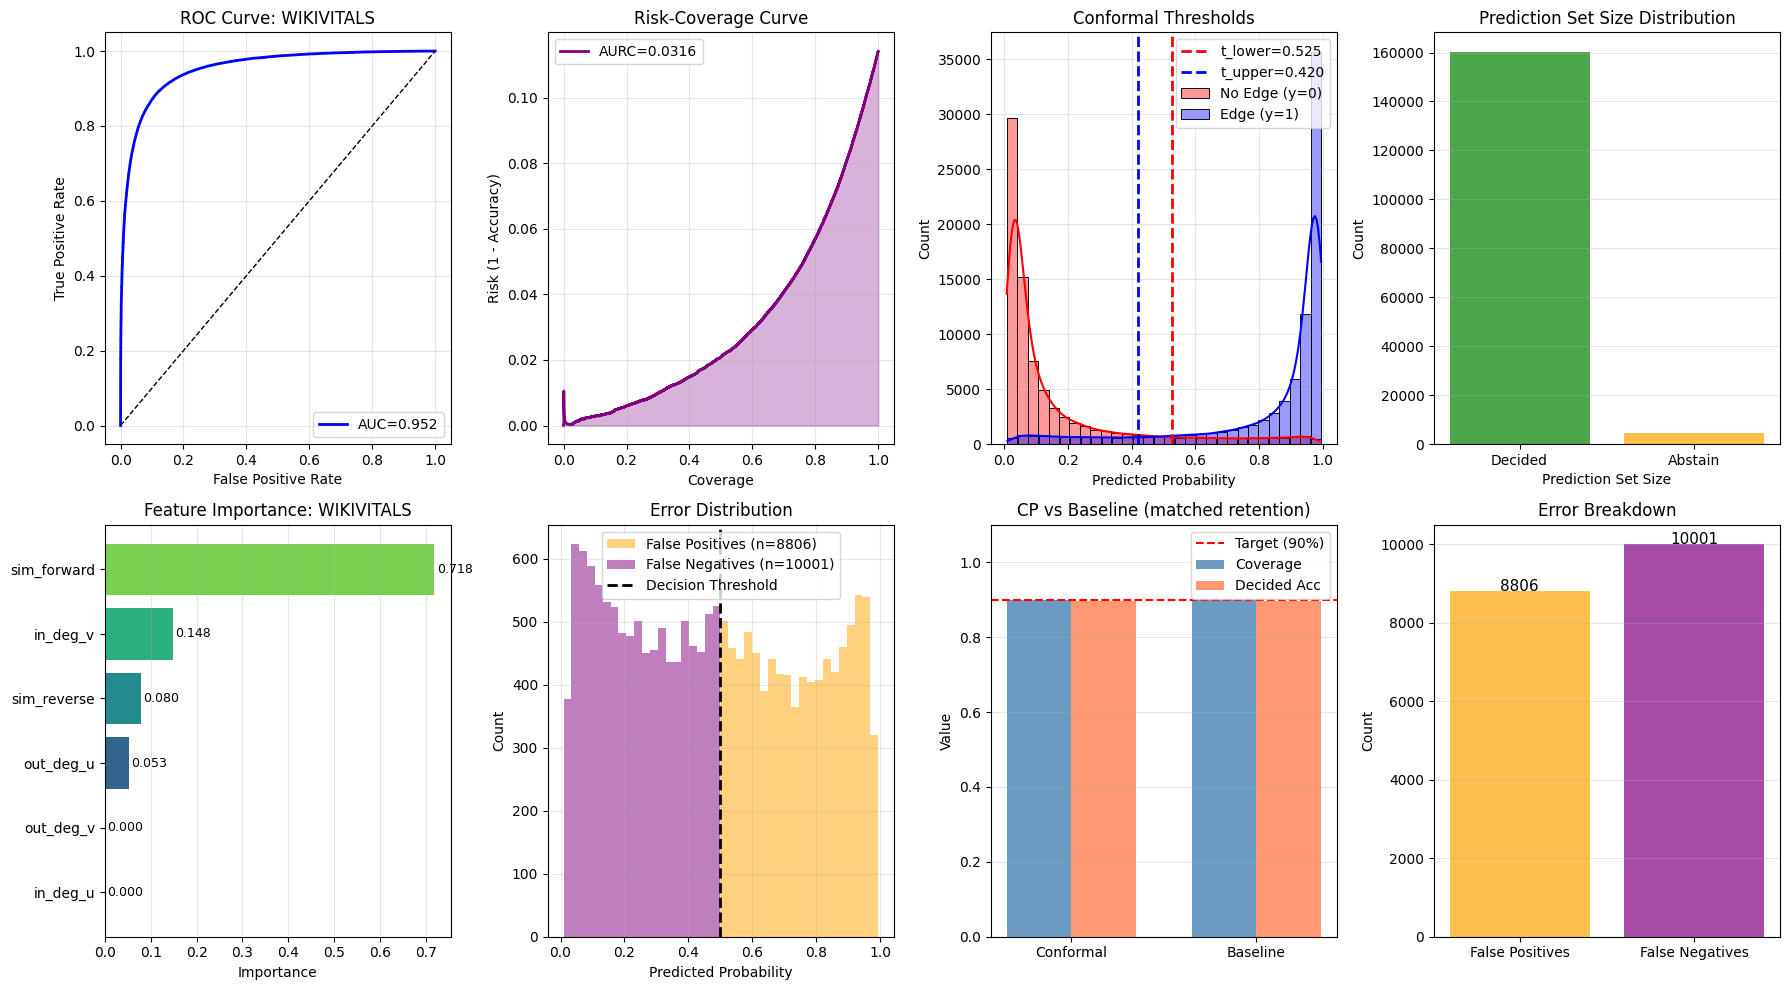


--- Analysis Summary ---
Feature Importance: {'out_deg_u': 0.053249846032127165, 'in_deg_v': 0.14825489653971435, 'in_deg_u': 9.818262487623893e-05, 'out_deg_v': 0.00040006575616301356, 'sim_forward': 0.7184795511785909, 'sim_reverse': 0.07951745786852837}
False Positives: 8806
False Negatives: 10001


In [22]:
results, analysis = run_directed_pipeline(
    adj_path="wikivitals/adjacency.tsv",
    name="Wikivitals",
    alpha=0.10,
    n_runs=10,
    n_components=32
)

print("\n--- Analysis Summary ---")
print(f"Feature Importance: {analysis['feature_importance']}")
print(f"False Positives: {analysis['n_false_positives']}")
print(f"False Negatives: {analysis['n_false_negatives']}")